In [3]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [6]:
# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
df = pd.read_csv(url, names=columns)

In [8]:
# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

In [11]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2025-12-03 18:33:35,181] A new study created in memory with name: no-name-e31fff7c-6e48-47a9-be42-ec0b5e731e64
[I 2025-12-03 18:33:37,076] Trial 0 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 193, 'max_depth': 7}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-12-03 18:33:38,093] Trial 1 finished with value: 0.7579143389199254 and parameters: {'n_estimators': 103, 'max_depth': 9}. Best is trial 0 with value: 0.7672253258845437.
[I 2025-12-03 18:33:39,030] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 99, 'max_depth': 17}. Best is trial 2 with value: 0.7709497206703911.
[I 2025-12-03 18:33:40,518] Trial 3 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 162, 'max_depth': 19}. Best is trial 3 with value: 0.7728119180633147.
[I 2025-12-03 18:33:42,174] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 180, 'max_depth': 15}. Best is trial 3 with value: 0.7728119

# visualizations in optuna

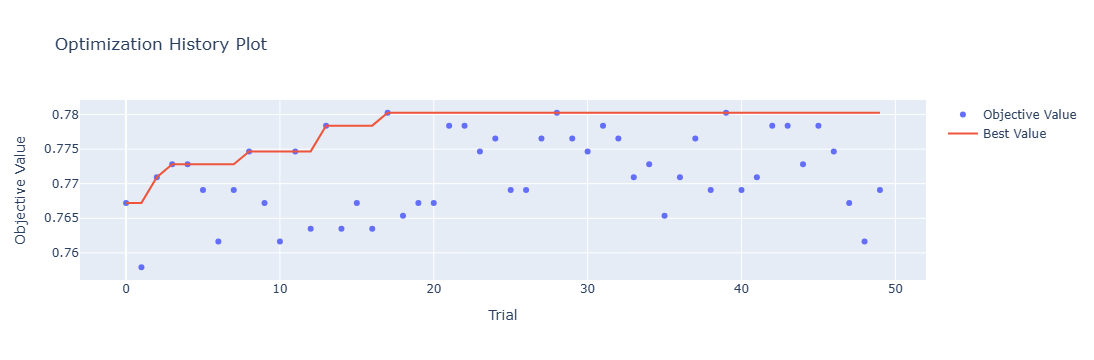

In [12]:
from optuna.visualization import plot_optimization_history

# 1. Optimization History
plot_optimization_history(study).show()

How accuracy is incraesing with each iteration

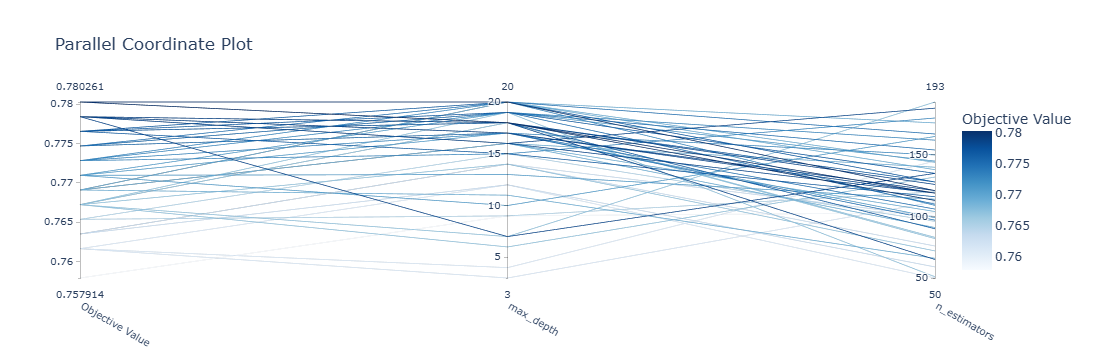

In [13]:
# 2. Parallel Coordinates Plot
from optuna.visualization import plot_parallel_coordinate
plot_parallel_coordinate(study).show()

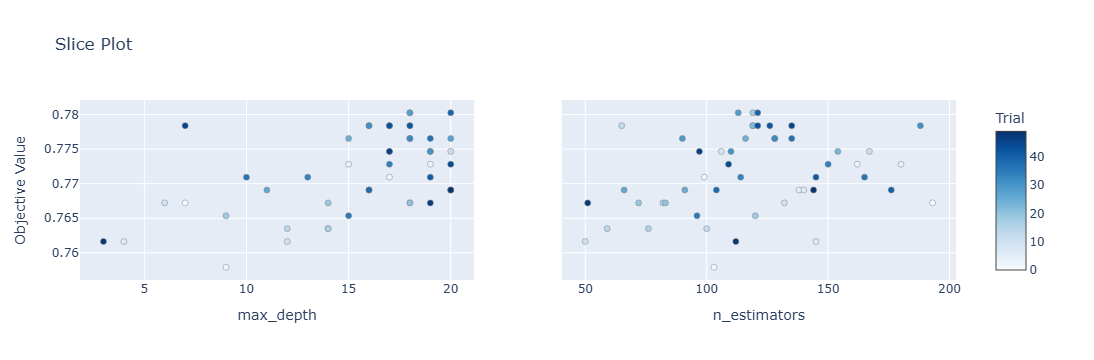

In [14]:
# 3. Slice Plot
from optuna.visualization import plot_slice
plot_slice(study).show()

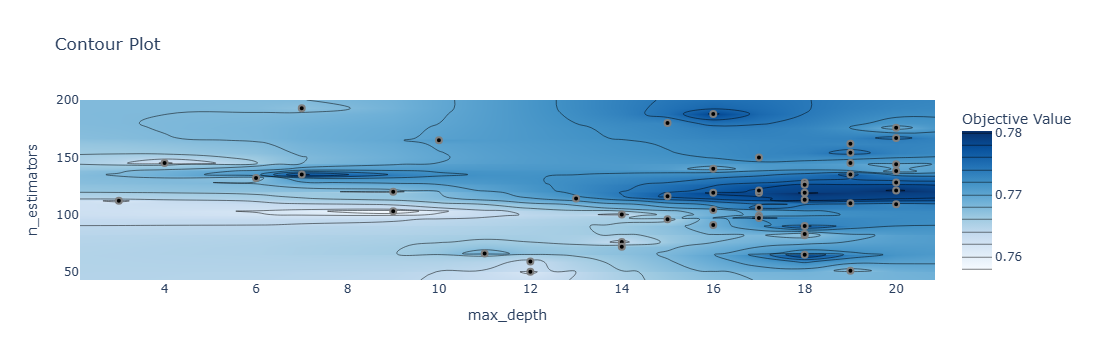

In [15]:
# 4. Contour Plot
from optuna.visualization import plot_contour
plot_contour(study).show()

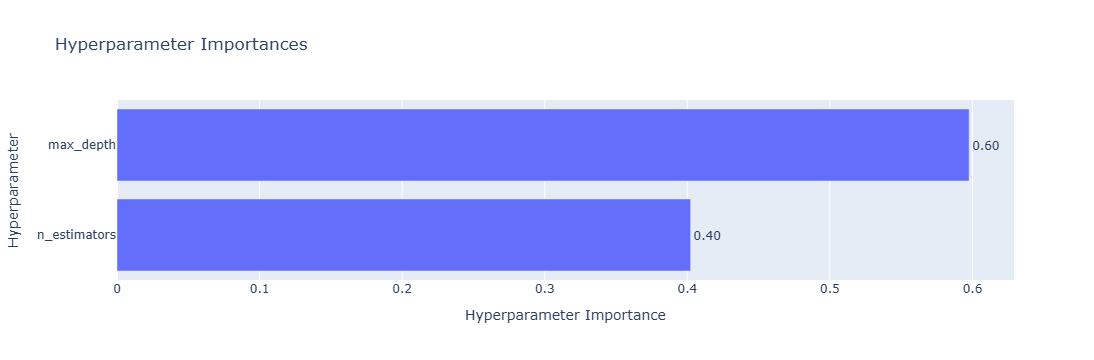

In [16]:
# 5. Hyperparameter Importance
from optuna.visualization import plot_param_importances
plot_param_importances(study).show()